In [1]:
import sys, importlib
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch import optim
from torch.utils.data import DataLoader, RandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper
import itertools
import time
import pickle
import os
from matplotlib import pyplot as plt
import torchtuples as tt
import copy
from lifelines.utils import concordance_index

from func_acc import loss_CoxPH,Net, SurvDataNN, traindata_custom, NN_regression, NN_CoxSNN

In [2]:
a32 = NN_CoxSNN(lr = 0.1/16, batch_size = 32 ,epochs = 100,loss_choice = loss_CoxPH, dropout_rt = None,num_hidden_node = 16)
a64 = NN_CoxSNN(lr = 0.1/8, batch_size = 64 ,epochs = 100,loss_choice = loss_CoxPH, dropout_rt = None,num_hidden_node = 16)
a128 = NN_CoxSNN(lr = 0.1/4, batch_size = 128 ,epochs = 100,loss_choice = loss_CoxPH, dropout_rt = None,num_hidden_node = 16)
a256 = NN_CoxSNN(lr = 0.1/2, batch_size = 256 ,epochs = 100,loss_choice = loss_CoxPH, dropout_rt = None,num_hidden_node = 16)
a512 = NN_CoxSNN(lr = 0.1, batch_size = 512 ,epochs = 100,loss_choice = loss_CoxPH, dropout_rt = None,num_hidden_node = 16)

<function matplotlib.pyplot.show(close=None, block=None)>

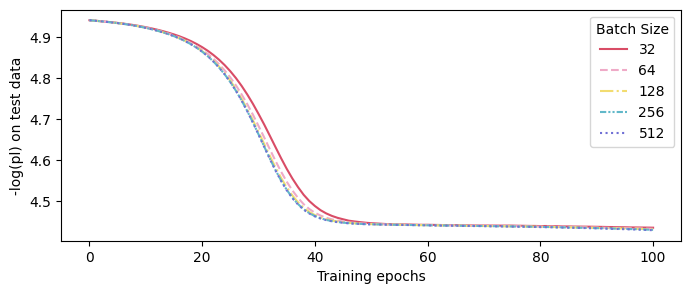

In [3]:
plt.figure(figsize=(8, 3))
plt.plot(a32.NN_testEpoch_FullPL,ls = '-',label = '32', color="#d94c66")
plt.plot(a64.NN_testEpoch_FullPL,ls = '--',label = '64',color="#EFAAC7")
plt.plot(a128.NN_testEpoch_FullPL,ls = '-.',label = '128',color="#f2dc70")
plt.plot(a256.NN_testEpoch_FullPL,ls = (0, (3, 1, 1, 1, 1, 1)),label = '256',color="#61B8C9")
plt.plot(a512.NN_testEpoch_FullPL,ls = ':',label = '512',color="#7070D5")
plt.legend(title = 'Batch Size',loc = 'upper right')
plt.ylabel('-log(pl) on test data')
plt.xlabel('Training epochs')
plt.show

In [4]:
b32 = NN_regression(lr = 0.01/16, batch_size = 32 ,epochs = 100,dropout_rt = None)
b64 = NN_regression(lr = 0.01/8, batch_size = 64 ,epochs = 100,dropout_rt = None)
b128 = NN_regression(lr = 0.01/4, batch_size = 128 ,epochs = 100,dropout_rt = None)
b256 = NN_regression(lr = 0.01/2, batch_size = 256 ,epochs = 100,dropout_rt = None)
b512 = NN_regression(lr = 0.01, batch_size = 512 ,epochs = 100,dropout_rt = None)

<function matplotlib.pyplot.show(close=None, block=None)>

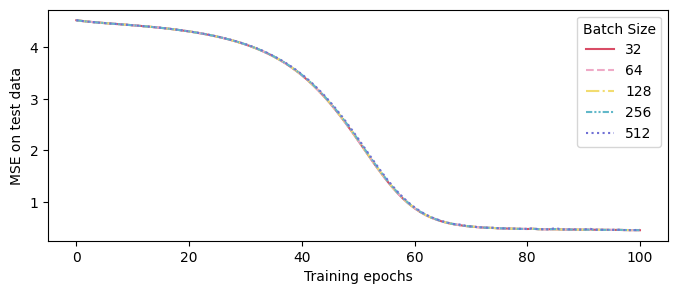

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(b32.NN_testEpoch_FullPL,ls = '-',label = '32', color="#d94c66")
plt.plot(b64.NN_testEpoch_FullPL,ls = '--',label = '64',color="#EFAAC7")
plt.plot(b128.NN_testEpoch_FullPL,ls = '-.',label = '128',color="#f2dc70")
plt.plot(b256.NN_testEpoch_FullPL,ls = (0, (3, 1, 1, 1, 1, 1)),label = '256',color="#61B8C9")
plt.plot(b512.NN_testEpoch_FullPL,ls = ':',label = '512',color="#7070D5")
plt.legend(title = 'Batch Size',loc = 'upper right')
plt.ylabel('MSE on test data')
plt.xlabel('Training epochs')
plt.show